In [2]:
# Imprimir información sobre la división
import pickle
with open("split_data_dict.pkl", "rb") as f:
    obj = pickle.load(f)

prueba = obj["prueba"]
split_data_dict = obj["split"]

for key, data in split_data_dict.items():
    print(f"Dataset: {key}")
    print(f"Tamaño de entrenamiento: {1 - prueba} | prueba: {prueba}")
    print(f"Min/Max de X_train: {data['train']['X'].min()}, {data['train']['X'].max()}")
    print(f"Min/Max de X_test: {data['test']['X'].min()}, {data['test']['X'].max()}")
    print(f"Tamaño -> X_train: {data['train']['X'].shape}, X_test: {data['test']['X'].shape}, "
          f"Y_train: {data['train']['Y'].shape}, Y_test: {data['test']['Y'].shape}\n")

Dataset: orig
Tamaño de entrenamiento: 0.8 | prueba: 0.2
Min/Max de X_train: 0.9745220898716793, 3.9621314639076735
Min/Max de X_test: 0.9748580503748066, 3.726623659510136
Tamaño -> X_train: (5756, 501), X_test: (1440, 501), Y_train: (5756, 1), Y_test: (1440, 1)

Dataset: sg
Tamaño de entrenamiento: 0.8 | prueba: 0.2
Min/Max de X_train: 0.9752886127765829, 3.5910473108689374
Min/Max de X_test: 0.9755120416313424, 3.4683186516323525
Tamaño -> X_train: (5756, 501), X_test: (1440, 501), Y_train: (5756, 1), Y_test: (1440, 1)

Dataset: msc
Tamaño de entrenamiento: 0.8 | prueba: 0.2
Min/Max de X_train: 1.0404674721382379, 3.6052977194138074
Min/Max de X_test: 1.0405483671078637, 3.396062387918411
Tamaño -> X_train: (5756, 501), X_test: (1440, 501), Y_train: (5756, 1), Y_test: (1440, 1)

Dataset: snv
Tamaño de entrenamiento: 0.8 | prueba: 0.2
Min/Max de X_train: -2.811475760461824, 2.2578953916480784
Min/Max de X_test: -2.8084884803188337, 1.846030072642991
Tamaño -> X_train: (5756, 501), X_

## HIPERPARAMETROS

In [16]:
filename = "best_hyperparams_all_models.pkl"

# 1. Cargar diccionario existente
with open(filename, "rb") as f:
    best_hyperparams = pickle.load(f)

# imprimir
print("\n=== Mejores Hiperparámetros ===")
for model_name, datasets in best_hyperparams.items():
    print(f"\nModelo: {model_name}")
    for dataset, result in datasets.items():
        print(f" Dataset: {dataset}")
        print("  Hiperparámetros:", result["best_params"])
        print(f"  Mejor MSE: {result['best_value']:.5f}")


=== Mejores Hiperparámetros ===

Modelo: random_forest
 Dataset: orig
  Hiperparámetros: {'n_estimators': 430, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  Mejor MSE: 18.45560
 Dataset: sg
  Hiperparámetros: {'n_estimators': 350, 'max_depth': 45, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  Mejor MSE: 13.86286
 Dataset: msc
  Hiperparámetros: {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  Mejor MSE: 20.70336
 Dataset: snv
  Hiperparámetros: {'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  Mejor MSE: 21.23559

Modelo: svr
 Dataset: orig
  Hiperparámetros: {'C': 29.958171631189153, 'epsilon': 0.04455338175146469, 'kernel': 'rbf', 'gamma': 0.007460250384322396}
  Mejor MSE: 21.35367
 Dataset: sg
  Hiperparámetros: {'C': 28.707297092891597, 'epsilon': 0.4504506686358284, 'kernel': 'rbf', 'ga

## DEFINICION DE METRICAS

In [17]:
# utils_modelos.py
import os
import numpy as np
import joblib
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def compute_metrics(y_true, y_pred, return_dict=True):
    """
    y_true, y_pred: 1D numpy arrays
    Devuelve RMSE, MAE, MAPE (%), R2, RPD
    RPD = std(y_true) / RMSE  (mayor = mejor)
    """
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    # MAPE seguro: evadir division por cero
    denom = np.where(np.isclose(y_true, 0.0), 1e-8, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

    r2 = r2_score(y_true, y_pred)
    std_y = np.std(y_true, ddof=1) if len(y_true) > 1 else 0.0
    rpd = std_y / (rmse + 1e-12) if rmse > 0 else np.inf

    if return_dict:
        return {"RMSE": rmse, "MAE": mae, "MAPE(%)": mape, "R2": r2, "RPD": rpd}
    else:
        return rmse, mae, mape, r2, rpd

def save_sklearn_model(model, path):
    ensure_dir(os.path.dirname(path))
    joblib.dump(model, path)

def load_sklearn_model(path):
    return joblib.load(path)

def save_torch_model(model, path):
    ensure_dir(os.path.dirname(path))
    torch.save(model.state_dict(), path)

def load_torch_model(model, path, device='cpu'):
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

In [3]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import os

# Directorio donde están los modelos RF (sin PCA)
rf_models_dir = "models/rf"  # ajusta si es otro

# Diccionario para guardar importancias
rf_importances = {}

for dataset in split_data_dict.keys():
    model_path = os.path.join(rf_models_dir, f"rf_{dataset}.joblib")
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        # El modelo es un Pipeline; el paso 'rf' es el RandomForestRegressor
        rf_step = model.named_steps['rf']
        importances = rf_step.feature_importances_
        rf_importances[dataset] = importances
        print(f"Dataset {dataset}: {len(importances)} variables, suma de importancias = {importances.sum():.4f}")
    else:
        print(f"Modelo no encontrado para {dataset}, debes entrenarlo primero.")

C:\Users\Sistema\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Sistema\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Sistema\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.2 when using version 1.5.1. This mi

Dataset orig: 501 variables, suma de importancias = 1.0000
Dataset sg: 501 variables, suma de importancias = 1.0000
Dataset msc: 501 variables, suma de importancias = 1.0000
Dataset snv: 501 variables, suma de importancias = 1.0000



Dataset orig:
  Total variables: 501
  Variables seleccionadas: 173 (mantienen 80.14% de importancia)
  Rango de longitudes de onda: 1100.0 - 1724.0 nm


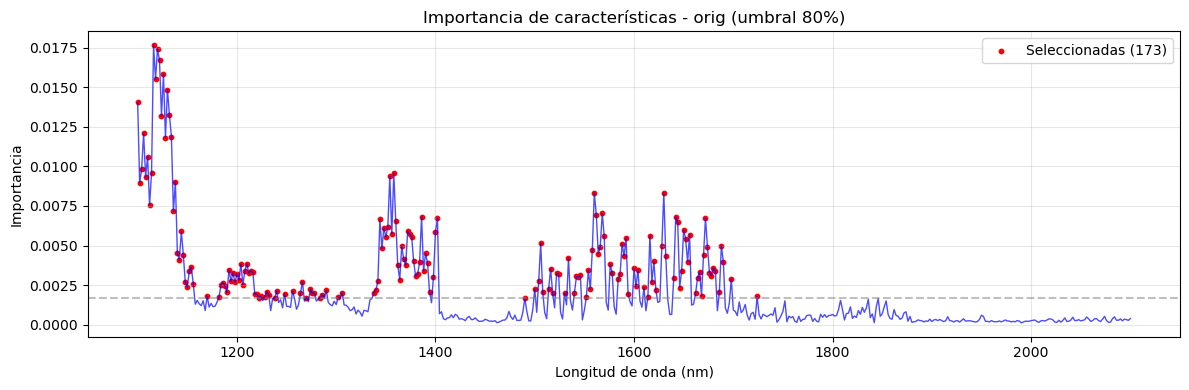


Dataset sg:
  Total variables: 501
  Variables seleccionadas: 199 (mantienen 80.06% de importancia)
  Rango de longitudes de onda: 1100.0 - 1854.0 nm


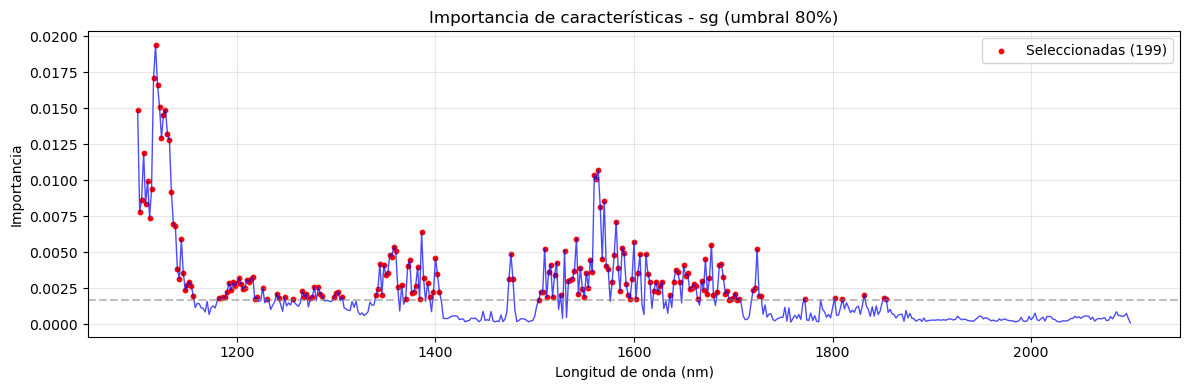


Dataset msc:
  Total variables: 501
  Variables seleccionadas: 111 (mantienen 80.22% de importancia)
  Rango de longitudes de onda: 1100.0 - 1676.0 nm


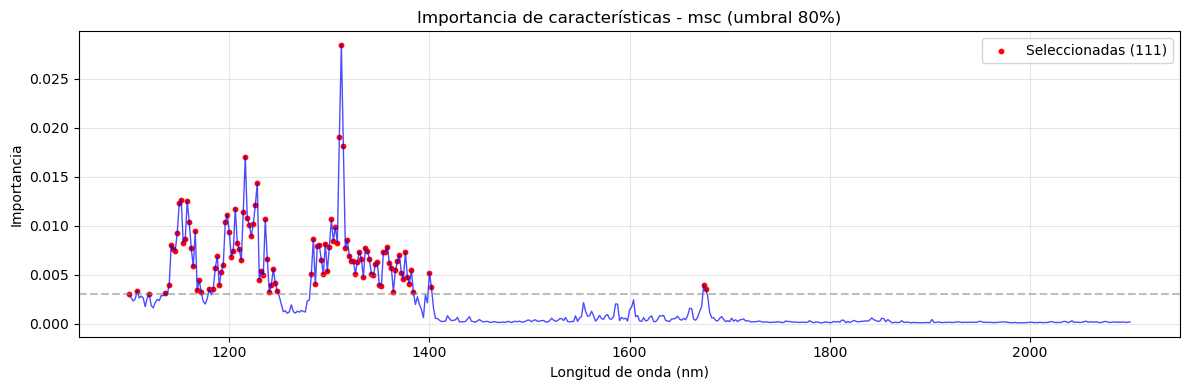


Dataset snv:
  Total variables: 501
  Variables seleccionadas: 110 (mantienen 80.11% de importancia)
  Rango de longitudes de onda: 1118.0 - 1678.0 nm


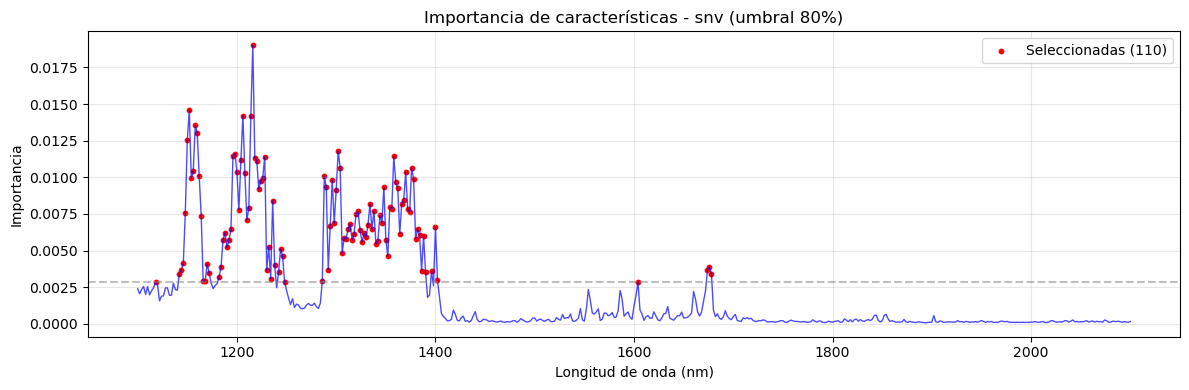

In [6]:
# Parámetro: fracción de importancia a mantener
IMPORTANCE_THRESHOLD = 0.80

selected_indices = {}
wavelengths = np.linspace(1100, 2100, 501)  # si no lo tienes definido

for dataset, imp in rf_importances.items():
    # Ordenar índices por importancia descendente
    sorted_idx = np.argsort(imp)[::-1]
    sorted_imp = imp[sorted_idx]
    
    # Calcular importancia acumulada
    cumsum = np.cumsum(sorted_imp)
    # Encontrar el punto donde se alcanza el umbral
    n_vars = np.searchsorted(cumsum, IMPORTANCE_THRESHOLD) + 1
    selected = sorted_idx[:n_vars]
    selected_indices[dataset] = selected
    
    print(f"\nDataset {dataset}:")
    print(f"  Total variables: {len(imp)}")
    print(f"  Variables seleccionadas: {n_vars} (mantienen {cumsum[n_vars-1]:.2%} de importancia)")
    print(f"  Rango de longitudes de onda: {wavelengths[selected].min():.1f} - {wavelengths[selected].max():.1f} nm")
    
    # Opcional: graficar importancias y las seleccionadas
    plt.figure(figsize=(12,4))
    plt.plot(wavelengths, imp, 'b-', linewidth=1, alpha=0.7)
    plt.scatter(wavelengths[selected], imp[selected], color='red', s=10, label=f'Seleccionadas ({n_vars})')
    plt.axhline(y=imp[selected[-1]], color='gray', linestyle='--', alpha=0.5)
    plt.xlabel('Longitud de onda (nm)')
    plt.ylabel('Importancia')
    plt.title(f'Importancia de características - {dataset} (umbral {IMPORTANCE_THRESHOLD:.0%})')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'figures/rf_importance_{dataset}.png', dpi=150)
    plt.show()